In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
#importo base 2005
from google.colab import files; uploaded=files.upload()  # elegí T105.dta
df_05= pd.read_stata("Individual_t105.dta")
df_05

Saving Individual_t105.dta to Individual_t105.dta


,CODUSU,nro_hogar,componente,h15,ano4,trimestre,region,mas_500,aglomerado,pondera,...,deccfr,ideccfr,rdeccfr,gdeccfr,pdeccfr,adeccfr,pj1_1,pj2_1,pj3_1,idimpp
0,125098,1.0,1.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1017.0,...,08,,07,08,,05,0.0,0.0,0.0,00000
1,125188,1.0,1.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1062.0,...,02,,02,02,,01,0.0,0.0,0.0,40020
2,125188,1.0,2.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1062.0,...,02,,02,02,,01,0.0,0.0,0.0,00000
3,125188,1.0,3.0,0.0,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1062.0,...,02,,02,02,,01,0.0,0.0,0.0,00000
4,125242,1.0,1.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1103.0,...,09,,09,09,,07,0.0,0.0,0.0,00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47025,288015,1.0,3.0,Sí,2005.0,1er. Trimestre,Patagónica,N,Ushuaia - Río Grande,129.0,...,09,10,09,,10,07,0.0,0.0,0.0,00000
47026,288015,1.0,4.0,Sí,2005.0,1er. Trimestre,Patagónica,N,Ushuaia - Río Grande,129.0,...,09,10,09,,10,07,0.0,0.0,0.0,00000
47027,288294,1.0,1.0,Sí,2005.0,1er. Trimestre,Patagónica,N,Ushuaia - Río Grande,107.0,...,10,10,09,,10,09,0.0,0.0,0.0,00000
47028,288294,1.0,2.0,Sí,2005.0,1er. Trimestre,Patagónica,N,Ushuaia - Río Grande,107.0,...,10,10,09,,10,09,0.0,0.0,0.0,00000


In [ ]:
#importo base 2025
from google.colab import files # elegir 2025
uploaded = files.upload()
fname = list(uploaded.keys())[0]

df_25 = pd.read_excel(fname)  # o pd.read_excel(fname, sheet_name="NombreDeHoja")
df_25.head()

Saving usu_individual_T125.xlsx to usu_individual_T125.xlsx


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNOVQVHJOLOCDEFKID00875778,2025,1,1,2,1,43,S,4,927,...,0,0,0,0,3.0,2.0,3.0,NaN,3.0,2.0
1,TQRMNOVQVHJOLOCDEFKID00875778,2025,1,1,3,0,43,S,4,927,...,0,0,0,0,3.0,2.0,3.0,NaN,3.0,2.0
2,TQRMNOVQVHJOLOCDEFKID00875778,2025,1,1,4,0,43,S,4,927,...,0,0,0,0,3.0,2.0,3.0,NaN,3.0,2.0
3,TQRMNOVQVHJOLOCDEFKID00875778,2025,1,1,5,0,43,S,4,927,...,0,0,0,0,3.0,2.0,3.0,NaN,3.0,2.0
4,TQRMNOUPQHLOLOCDEFKID00851757,2025,1,1,1,1,43,S,4,1294,...,0,0,0,0,3.0,3.0,3.0,NaN,3.0,3.0


# PARTE UNO

In [ ]:
#cambiar region a codigo en la de 05

def regioncodigo (region):
    if region == 'Gran Buenos Aires':
        return 1
    elif region == 'NOA':
        return 40
    elif region == 'NEA':
        return 41
    elif region == 'Cuyo':
        return 42
    elif region == 'Pampeana':
        return 43
    elif region == 'Patagónica':
        return 44


In [ ]:
# Mirá los strings “tal cual” para detectar \xa0, \t, \n, etc.
for s in df_05['region'].dropna().unique()[:10]:
    print(repr(s))


'Gran Buenos Aires'
'NOA'
'NEA'
'Cuyo'
'Pampeana'
'Patagónica'


In [ ]:
# Apply the regioncodigo function to the 'region' column
df_05["region"] = df_05["region"].apply(regioncodigo)

# Check the unique values in the 'region' column after applying the function
print(df_05["region"].unique())

df_05.sample(15)

[1, 40, 41, 42, 43, 44]
Categories (6, int64): [1 < 40 < 41 < 42 < 43 < 44]


,CODUSU,nro_hogar,componente,h15,ano4,trimestre,region,mas_500,aglomerado,pondera,...,deccfr,ideccfr,rdeccfr,gdeccfr,pdeccfr,adeccfr,pj1_1,pj2_1,pj3_1,idimpp
6672,223678,1.0,1.0,Sí,2005.0,1er. Trimestre,1,S,Partidos del GBA,1297.0,...,01,,01,01,,01,0.0,0.0,0.0,00000
26878,169709,1.0,1.0,Sí,2005.0,1er. Trimestre,42,N,San Luis - El Chorrillo,172.0,...,03,03,03,,04,03,0.0,0.0,0.0,00000
27632,129693,1.0,3.0,Sí,2005.0,1er. Trimestre,42,N,Gran San Juan,483.0,...,02,02,02,,03,03,0.0,0.0,0.0,00000
24017,244434,1.0,4.0,0.0,2005.0,1er. Trimestre,41,N,Formosa,231.0,...,10,10,10,,10,10,0.0,0.0,0.0,00000
22717,224459,1.0,1.0,Sí,2005.0,1er. Trimestre,41,N,Corrientes,384.0,...,08,09,09,,09,10,0.0,0.0,0.0,00000
42714,262043,1.0,1.0,Sí,2005.0,1er. Trimestre,43,S,Mar del Plata - Batán,170.0,...,07,07,07,06,,06,0.0,0.0,0.0,00000
9531,130468,3.0,1.0,Sí,2005.0,1er. Trimestre,40,N,Santiago del Estero - La Banda,257.0,...,10,10,10,,10,10,0.0,0.0,0.0,00000
21804,285785,1.0,2.0,Sí,2005.0,1er. Trimestre,41,N,Gran Resistencia,273.0,...,02,02,04,,03,04,0.0,0.0,0.0,40100
28904,260170,1.0,3.0,Sí,2005.0,1er. Trimestre,42,N,Gran San Juan,259.0,...,03,04,04,,04,04,0.0,0.0,0.0,00000
41098,233906,1.0,5.0,Sí,2005.0,1er. Trimestre,43,N,Santa Rosa - Toay,228.0,...,03,03,03,,04,03,0.0,0.0,0.0,00000


In [ ]:
# Filtro las dos bases para quedarme con Patagonia (44)
#2005
df_05_pat= df_05[df_05["region"] == 44].copy()
df_05_pat.sample(5)

,CODUSU,nro_hogar,componente,h15,ano4,trimestre,region,mas_500,aglomerado,pondera,...,deccfr,ideccfr,rdeccfr,gdeccfr,pdeccfr,adeccfr,pj1_1,pj2_1,pj3_1,idimpp
46458,178512,1.0,1.0,Sí,2005.0,1er. Trimestre,44,N,Ushuaia - Río Grande,157.0,...,10,10,10,,10,10,0.0,0.0,0.0,00000
45343,268250,1.0,4.0,Sí,2005.0,1er. Trimestre,44,N,Neuquén - Plottier,261.0,...,06,07,05,,07,07,0.0,0.0,0.0,00000
45948,225276,1.0,3.0,Sí,2005.0,1er. Trimestre,44,N,Río Gallegos,94.0,...,04,05,03,,05,02,0.0,0.0,0.0,00000
46337,148057,1.0,2.0,Sí,2005.0,1er. Trimestre,44,N,Ushuaia - Río Grande,178.0,...,02,02,01,,02,01,0.0,0.0,Tiene plan jefas y jefes,00000
45697,181540,2.0,2.0,Sí,2005.0,1er. Trimestre,44,N,Río Gallegos,142.0,...,06,07,05,,07,03,0.0,0.0,0.0,00000


In [ ]:
# Filtro las dos bases para quedarme con Patagonia (44)
#2025
df_25_pat= df_25[df_25["REGION"] == 44].copy()
df_25_pat.sample(5)


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
27745,TQRMNORPVHMNKNCDEIHJF00880546,2025,1,1,2,0,44,N,31,224,...,0,0,0,0,6.0,5.0,NaN,7.0,7.0,4.0
41669,TQRMNOTWWHKOLQCDEGNFJ00860495,2025,1,1,2,1,44,N,17,195,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
30601,TQRMNOQUYHLOLQCDEFPCH00874154,2025,1,1,2,1,44,N,9,272,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
30639,TQRMNORUUHKOKOCDEOJAH00860549,2025,1,1,4,0,44,N,93,58,...,0,0,0,0,8.0,7.0,NaN,9.0,9.0,8.0
27485,TQRMNOSYPHKLLMCDEHGHJ00856910,2025,1,1,3,1,44,N,20,467,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
##### ELIJO LAS 15 VARS: CH04, CH06, CH07, CH08, NIVEL ED, ESTADO, CAT_INAC, IPCF, CH15, PP10A, PP3E_TOT, PP3F_TOT, PP07A, PP10E, CAT_OCUP + año


In [ ]:
print(df_05_pat.columns.tolist()) #para ver que onda los conmbres de vars 2005

['CODUSU', 'nro_hogar', 'componente', 'h15', 'ano4', 'trimestre', 'region', 'mas_500', 'aglomerado', 'pondera', 'ch03', 'ch04', 'ch06', 'ch07', 'ch08', 'ch09', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch15_cod', 'ch16', 'ch16_cod', 'nivel_ed', 'estado', 'cat_ocup', 'cat_inac', 'pp02c1', 'pp02c2', 'pp02c3', 'pp02c4', 'pp02c5', 'pp02c6', 'pp02c7', 'pp02c8', 'pp02e', 'pp02h', 'pp02i', 'pp03c', 'pp03d', 'pp3e_tot', 'pp3f_tot', 'pp03g', 'pp03h', 'pp03i', 'pp03j', 'intensi', 'pp04a', 'pp04b_cod', 'pp04b1', 'pp04b2', 'pp04b3_mes', 'pp04b3_ano', 'pp04b3_dia', 'pp04c', 'pp04c99', 'pp04d_cod', 'pp04g', 'pp05b2_mes', 'pp05b2_ano', 'pp05b2_dia', 'pp05c_1', 'pp05c_2', 'pp05c_3', 'pp05e', 'pp05f', 'pp05h', 'pp06a', 'pp06c', 'pp06d', 'pp06e', 'pp06h', 'pp07a', 'pp07c', 'pp07d', 'pp07e', 'pp07f1', 'pp07f2', 'pp07f3', 'pp07f4', 'pp07f5', 'pp07g1', 'pp07g2', 'pp07g3', 'pp07g4', 'pp07g_59', 'pp07h', 'pp07i', 'pp07j', 'pp07k', 'pp08d1', 'pp08d4', 'pp08f1', 'pp08f2', 'pp08j1', 'pp08j2', 'pp08j3', '

In [ ]:
print(df_25_pat.columns.tolist()) #para ver que onda los conmbres de vars 2025

['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'H15', 'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA', 'CH03', 'CH04', 'CH05', 'CH06', 'CH07', 'CH08', 'CH09', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'CH15', 'CH15_COD', 'CH16', 'CH16_COD', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'CAT_INAC', 'IMPUTA', 'PP02C1', 'PP02C2', 'PP02C3', 'PP02C4', 'PP02C5', 'PP02C6', 'PP02C7', 'PP02C8', 'PP02E', 'PP02H', 'PP02I', 'PP03C', 'PP03D', 'PP3E_TOT', 'PP3F_TOT', 'PP03G', 'PP03H', 'PP03I', 'PP03J', 'INTENSI', 'PP04A', 'PP04B_COD', 'PP04B1', 'PP04B2', 'PP04B3_MES', 'PP04B3_ANO', 'PP04B3_DIA', 'PP04C', 'PP04C99', 'PP04D_COD', 'PP04G', 'PP05B2_MES', 'PP05B2_ANO', 'PP05B2_DIA', 'PP05C_1', 'PP05C_2', 'PP05C_3', 'PP05E', 'PP05F', 'PP05H', 'PP06A', 'PP06C', 'PP06D', 'PP06E', 'PP06H', 'PP07A', 'PP07C', 'PP07D', 'PP07E', 'PP07F1', 'PP07F2', 'PP07F3', 'PP07F4', 'PP07F5', 'PP07G1', 'PP07G2', 'PP07G3', 'PP07G4', 'PP07G_59', 'PP07H', 'PP07I', 'PP07J', 'PP07K', 'PP08D1', 'PP08D4', 'PP08F1', 'PP08F2', 'PP08J1', 'PP

In [ ]:
#pongo titulo y contenido todo en mayuscula 2005
df_05_pat.columns = df_05_pat.columns.str.upper()
print(df_05_pat.columns.tolist())

df_05_pat.sample(15)

['CODUSU', 'NRO_HOGAR', 'COMPONENTE', 'H15', 'ANO4', 'TRIMESTRE', 'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA', 'CH03', 'CH04', 'CH06', 'CH07', 'CH08', 'CH09', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'CH15', 'CH15_COD', 'CH16', 'CH16_COD', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'CAT_INAC', 'PP02C1', 'PP02C2', 'PP02C3', 'PP02C4', 'PP02C5', 'PP02C6', 'PP02C7', 'PP02C8', 'PP02E', 'PP02H', 'PP02I', 'PP03C', 'PP03D', 'PP3E_TOT', 'PP3F_TOT', 'PP03G', 'PP03H', 'PP03I', 'PP03J', 'INTENSI', 'PP04A', 'PP04B_COD', 'PP04B1', 'PP04B2', 'PP04B3_MES', 'PP04B3_ANO', 'PP04B3_DIA', 'PP04C', 'PP04C99', 'PP04D_COD', 'PP04G', 'PP05B2_MES', 'PP05B2_ANO', 'PP05B2_DIA', 'PP05C_1', 'PP05C_2', 'PP05C_3', 'PP05E', 'PP05F', 'PP05H', 'PP06A', 'PP06C', 'PP06D', 'PP06E', 'PP06H', 'PP07A', 'PP07C', 'PP07D', 'PP07E', 'PP07F1', 'PP07F2', 'PP07F3', 'PP07F4', 'PP07F5', 'PP07G1', 'PP07G2', 'PP07G3', 'PP07G4', 'PP07G_59', 'PP07H', 'PP07I', 'PP07J', 'PP07K', 'PP08D1', 'PP08D4', 'PP08F1', 'PP08F2', 'PP08J1', 'PP08J2', 'PP08J3', '

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,DECCFR,IDECCFR,RDECCFR,GDECCFR,PDECCFR,ADECCFR,PJ1_1,PJ2_1,PJ3_1,IDIMPP
46927,274216,1.0,1.0,Sí,2005.0,1er. Trimestre,44,N,Ushuaia - Río Grande,124.0,...,09,10,09,,10,08,0.0,0.0,0.0,00000
45256,247957,1.0,1.0,Sí,2005.0,1er. Trimestre,44,N,Neuquén - Plottier,245.0,...,05,06,04,,06,05,0.0,0.0,0.0,00000
44281,219071,1.0,1.0,Sí,2005.0,1er. Trimestre,44,N,Comodoro Rivadavia - Rada Tilly,185.0,...,02,03,02,,03,02,0.0,0.0,0.0,10000
45388,276161,1.0,3.0,Sí,2005.0,1er. Trimestre,44,N,Neuquén - Plottier,289.0,...,06,07,05,,07,07,0.0,0.0,0.0,00000
44153,196531,1.0,1.0,Sí,2005.0,1er. Trimestre,44,N,Comodoro Rivadavia - Rada Tilly,121.0,...,07,07,06,,08,05,0.0,0.0,0.0,00000
46711,236581,1.0,1.0,Sí,2005.0,1er. Trimestre,44,N,Ushuaia - Río Grande,127.0,...,10,10,10,,10,09,0.0,0.0,0.0,00000
43976,161023,1.0,1.0,Sí,2005.0,1er. Trimestre,44,N,Comodoro Rivadavia - Rada Tilly,221.0,...,09,10,09,,10,08,0.0,0.0,0.0,00000
43925,149184,1.0,1.0,Sí,2005.0,1er. Trimestre,44,N,Comodoro Rivadavia - Rada Tilly,147.0,...,03,03,02,,04,02,0.0,0.0,0.0,00000
46992,283213,1.0,1.0,Sí,2005.0,1er. Trimestre,44,N,Ushuaia - Río Grande,145.0,...,10,10,10,,10,10,0.0,0.0,0.0,00000
44053,173514,1.0,7.0,0.0,2005.0,1er. Trimestre,44,N,Comodoro Rivadavia - Rada Tilly,79.0,...,01,02,01,,02,01,0.0,0.0,0.0,00000


In [ ]:
#pongo titulo y contenido todo en mayuscula 2025
df_25_pat.columns = df_25_pat.columns.str.upper()
print(df_25_pat.columns.tolist())

df_25_pat.sample(10)

['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'H15', 'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA', 'CH03', 'CH04', 'CH05', 'CH06', 'CH07', 'CH08', 'CH09', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'CH15', 'CH15_COD', 'CH16', 'CH16_COD', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'CAT_INAC', 'IMPUTA', 'PP02C1', 'PP02C2', 'PP02C3', 'PP02C4', 'PP02C5', 'PP02C6', 'PP02C7', 'PP02C8', 'PP02E', 'PP02H', 'PP02I', 'PP03C', 'PP03D', 'PP3E_TOT', 'PP3F_TOT', 'PP03G', 'PP03H', 'PP03I', 'PP03J', 'INTENSI', 'PP04A', 'PP04B_COD', 'PP04B1', 'PP04B2', 'PP04B3_MES', 'PP04B3_ANO', 'PP04B3_DIA', 'PP04C', 'PP04C99', 'PP04D_COD', 'PP04G', 'PP05B2_MES', 'PP05B2_ANO', 'PP05B2_DIA', 'PP05C_1', 'PP05C_2', 'PP05C_3', 'PP05E', 'PP05F', 'PP05H', 'PP06A', 'PP06C', 'PP06D', 'PP06E', 'PP06H', 'PP07A', 'PP07C', 'PP07D', 'PP07E', 'PP07F1', 'PP07F2', 'PP07F3', 'PP07F4', 'PP07F5', 'PP07G1', 'PP07G2', 'PP07G3', 'PP07G4', 'PP07G_59', 'PP07H', 'PP07I', 'PP07J', 'PP07K', 'PP08D1', 'PP08D4', 'PP08F1', 'PP08F2', 'PP08J1', 'PP

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
5205,TQRMNORSRHMLKPCDEFPCH00878261,2025,1,1,2,1,44,N,9,458,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
11143,TQRMNOPWTHMLKQCDEGNFJ00878817,2025,1,1,1,1,44,N,17,163,...,0,0,0,0,2.0,1.0,NaN,2.0,2.0,2.0
20976,TQRMNOSPUHJLLMCDEGNFJ00874753,2025,1,1,4,1,44,N,17,314,...,0,0,0,0,9.0,8.0,NaN,10.0,10.0,8.0
21105,TQRMNOSRUHJLKTCDEGNFJ00874892,2025,1,1,1,1,44,N,17,197,...,0,0,0,0,5.0,3.0,NaN,6.0,6.0,3.0
14945,TQRMNOSQQHMOKMCDEHGHJ00879259,2025,1,1,2,1,44,N,20,246,...,0,0,0,0,10.0,10.0,NaN,10.0,10.0,10.0
17655,TQRMNORVPHMNLLCDEHGHJ00879700,2025,1,1,4,1,44,N,20,260,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
15663,TQRMNORRSHJOKTCDEIHJF00873263,2025,1,1,7,1,44,N,31,127,...,0,0,0,0,5.0,3.0,NaN,5.0,5.0,3.0
26974,TQRMNOQSQHJMKRCDEHGHJ00880731,2025,1,1,3,1,44,N,20,314,...,0,0,0,0,7.0,6.0,NaN,7.0,8.0,6.0
43108,TQRMNORPQHKNLMCDEFPCH00863217,2025,1,1,1,1,44,N,9,205,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
25606,TQRMNOPVVHJMLNCDEHGHJ00880253,2025,1,1,2,1,44,N,20,86,...,0,0,0,0,9.0,8.0,NaN,9.0,9.0,8.0


In [ ]:
#lista de variables
var= ["CH04", "CH06", "CH07", "CH08", "NIVEL_ED", "ESTADO", "CAT_INAC", "IPCF", "CH15", "CH09", "PP10A", "PP3E_TOT", "PP07A", "PP10E", "CAT_OCUP", "ANO4"]


In [ ]:
#reduzco los df a las variables de interes

df_05int= df_05_pat[var]
df_25int= df_25_pat[var]

In [ ]:
#para ver si quedaron las mismas cant de columnas
print("df05", df_05int.shape)
print("df25", df_25int.shape)

print("lista de variables:", df_05int.columns.tolist())
print("lista de variables:", df_25int.columns.tolist())

df05 (3229, 16)
df25 (5359, 16)
lista de variables: ['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'IPCF', 'CH15', 'CH09', 'PP10A', 'PP3E_TOT', 'PP07A', 'PP10E', 'CAT_OCUP', 'ANO4']
lista de variables: ['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'IPCF', 'CH15', 'CH09', 'PP10A', 'PP3E_TOT', 'PP07A', 'PP10E', 'CAT_OCUP', 'ANO4']


In [ ]:
#hago direccionarios para re-codificar la base de 20005 para que este de la misma forma que la de 2025 y asi poder juntarlas
 #CHO4
sexo= {"Varón":1, "Mujer":2}
#CH06 -> es numerica deberia estar bien
#CH07
est_civil= {"Unido":1, "Casado":2, "Separado o divorciado":3, "Viudo":4, "Soltero":5}
#CH08
cob_medica={"Obra social (incluye PAMI)":1, 'Mutual/Prepaga/Servicio de emergencia':2, 'Planes y seguros públicos':3, "No paga ni le descuentan":4, 'Ns./Nr.':9, "Obra social y mutual/prepaga/servicio de emergencia":12, 'Obra social y planes y seguros públicos':13, 'Mutual/prepaga/servicio de emergencia/planesysegurospúblicos':23, "Obra social, mutual/prepaga/serviciodeemergenciayPlanesySegurosPúblicos":123}
#NIVEL_ED
nivel_ed={'Primaria Incompleta (incluye educación especial)':1,  'Primaria Completa':2, "Secundaria Incompleta":3, "Secundaria Completa":4, 'Superior Universitaria Incompleta':5, 'Superior Universitaria Completa':6, 'Sin instrucción': 7, "Ns./Nr": 9}
#ESTADO
cond_act= {'Entrevista individual no realizada (no respuesta al cuestion':0, 'Ocupado':1, "Desocupado":2, "Inactivo":3, "Menor de 10 años":4}
#CAT_INAC
inactividad= {"Jubilado/pensionado":1, "Rentista":2, "Estudiante":3, "Ama de casa":4, "Menor de 6 años":5, "Discapacitado":6, "Otros":7}
#IPCF -> es numerica
#CH15
nacimiento= {'En esta localidad':1, 'En otra localidad':2, 'En otra provincia (especificar)':3, 'En un país limítrofe':4, 'En otro país':5, "Ns./Nr": np.nan}
#CH09 - alfabetización
alfab= {"Sí":1, "No":2, "Menor de 2 años":3}
#PP10A
busca_trab= {'...menos de 1 mes?':1, '...de 1 a 3 meses?':2, '...más de 3 a 6 meses?':3, '...más de 6 a 12 meses?':4, '...más de 1 año?':5, 'Ns./Nr.':np.nan, 0: np.nan}
#PP3E_TOT -> horas en ocupación en la semana
#PP07A
tiempo_trabajando= {'Menos de un mes':1, '1 a 3 meses':2, 'Más de 3 a 6 meses':3,'Más de 6 a 12 meses':4, 'Más de 1 a 5 años':5, 'Más de 5 años':6, "Ns./Nr.": np.nan, 0: np.nan}
#PP10E
tiempo_desocupado= {'...menos de 1 mes?':1, '...de 1 a 3 meses?':2, '...más de 3 a 6 meses?':3, '...más de 6 a 12 meses?':4, '...más de 1 a 3 años?':5, '...más de 3 años?':6, 'Ns./Nr.':np.nan, 0: np.nan}
#CAT_OCUP: categoria de ocupacion
cat_ocup= {'Patrón':1,'Cuenta propia':2, 'Obrero o empleado':3, 'Trabajador familiar sin remuneración':4}

In [ ]:
import numpy as np  # asegúrate de tener esto
# Diccionarios 'sexo', 'est_civil', 'cob_medica', etc. deben estar definidos antes

cols_to_replace = ["CH04", "CH07", "CH08", "NIVEL_ED", "ESTADO", "CAT_INAC", "CH15", "CH09", "PP10A", "PP07A", "PP10E", "CAT_OCUP"]

for col in cols_to_replace:
    if col in df_05int.columns:
        # Evita problemas de tipos mezclados
        df_05int.loc[:, col] = df_05int[col].astype('object')

        # Elegí el diccionario correcto según la columna
        mapping = (sexo              if col == "CH04"     else
                   est_civil         if col == "CH07"     else
                   cob_medica        if col == "CH08"     else
                   nivel_ed          if col == "NIVEL_ED" else
                   cond_act          if col == "ESTADO"   else
                   inactividad       if col == "CAT_INAC" else
                   nacimiento        if col == "CH15"     else
                   alfab             if col == "CH09"     else
                   busca_trab        if col == "PP10A"    else
                   tiempo_trabajando if col == "PP07A"    else
                   tiempo_desocupado if col == "PP10E"    else
                   cat_ocup          if col == "CAT_OCUP" else {})

        # Reemplaza por el código numérico; si no está en el diccionario → NaN
        df_05int.loc[:, col] = df_05int[col].apply(lambda x: mapping.get(x, np.nan))


/tmp/ipython-input-1717674863.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1, 2, 1, 1, 2, ..., 2, 1, 1, 2, 2]
Length: 3229
Categories (2, int64): [1 < 2]' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  df_05int.loc[:, col] = df_05int[col].apply(lambda x: mapping.get(x, np.nan))
/tmp/ipython-input-1717674863.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2. 2. 5. ... 1. 1. 5.]' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  df_05int.loc[:, col] = df_05int[col].apply(lambda x: mapping.get(x, np.nan))
/tmp/ipython-input-1717674863.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1. 1. 1. ... 1. 1. 1.]' has dtype incompatible with category, please explicitly cast to a 

In [ ]:
df_05int.sample() #para cheqeuar que este bien

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH15,CH09,PP10A,PP3E_TOT,PP07A,PP10E,CAT_OCUP,ANO4
43895,2,35.0,3.0,1.0,5,1,NaN,640.0,1.0,1.0,NaN,98.0,5.0,NaN,3.0,2005.0


In [ ]:
df_25int.sample() #chequeo

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH15,CH09,PP10A,PP3E_TOT,PP07A,PP10E,CAT_OCUP,ANO4
17711,2,19,5,1.0,5,3,3,1600000.0,1,1,NaN,NaN,NaN,NaN,0,2025


In [ ]:
##### AGRUPO LAS DOS BASES DE DATOS
df_05y25= pd.concat([df_05int, df_25int])
df_05y25

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH15,CH09,PP10A,PP3E_TOT,PP07A,PP10E,CAT_OCUP,ANO4
43801,1,46.0,2.0,1.0,3,1,NaN,480.0,3.0,1.0,NaN,48.0,6.0,NaN,3.0,2005.0
43802,2,32.0,2.0,1.0,3,3,4.0,480.0,3.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0
43803,1,14.0,5.0,1.0,2,3,3.0,480.0,3.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0
43804,1,9.0,5.0,1.0,1,4,3.0,480.0,1.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0
43805,2,3.0,5.0,1.0,7,4,5.0,480.0,1.0,2.0,NaN,0.0,NaN,NaN,NaN,2005.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45295,2,55,1.0,3.0,4,3,4.0,87500.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,2025.0
45296,1,49,1.0,3.0,1,1,0.0,87500.0,3.0,1.0,NaN,16.0,0.0,NaN,2.0,2025.0
45297,1,35,5.0,3.0,1,3,6.0,87500.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,2025.0
45326,2,26,5.0,3.0,3,1,0.0,87500.0,1.0,1.0,NaN,36.0,0.0,NaN,3.0,2025.0


In [ ]:
# para comprobar que esten las dos bases- yey estan
df_05y25["ANO4"].unique()

array([2005., 2025.])

In [ ]:
#CAMBIO NOMBRE A LAS VARIABLES
rename_cols = {
    "CH04": "sexo",
    "CH07": "est_civil",
    "CH08": "cob_medica",
    "NIVEL_ED": "nivel_ed",
    "ESTADO": "cond_act",
    "CAT_INAC": "inactividad",
    "CH15": "nacimiento",
    "CH09": "alfab",
    "PP10A": "busca_trab",
    "PP07A": "tiempo_trabajando",
    "PP10E": "tiempo_desocupado",
    "CAT_OCUP": "cat_ocup",
    "ANO4": "año",
    "PP3E_TOT": "horas_ocup",
    "IPCF": "ingreso_PCF",
    "CH06": "edad"}

df_05y25t = df_05y25.rename(columns=rename_cols)
df_05y25t.head()

,sexo,edad,est_civil,cob_medica,nivel_ed,cond_act,inactividad,ingreso_PCF,nacimiento,alfab,busca_trab,horas_ocup,tiempo_trabajando,tiempo_desocupado,cat_ocup,año
43801,1,46.0,2.0,1.0,3,1,NaN,480.0,3.0,1.0,NaN,48.0,6.0,NaN,3.0,2005.0
43802,2,32.0,2.0,1.0,3,3,4.0,480.0,3.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0
43803,1,14.0,5.0,1.0,2,3,3.0,480.0,3.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0
43804,1,9.0,5.0,1.0,1,4,3.0,480.0,1.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0
43805,2,3.0,5.0,1.0,7,4,5.0,480.0,1.0,2.0,NaN,0.0,NaN,NaN,NaN,2005.0


In [ ]:
year_candidates = ["año","ANO4","anio","ano"]
year_col = next((c for c in df_05y25.columns if str(c).lower() in [s.lower() for s in year_candidates]), None)
assert year_col is not None, f"No encuentro columna de año. Columnas: {list(df_05y25.columns)}"


In [ ]:
vars15 = ["CH04","CH06","CH07","CH08","NIVEL_ED","ESTADO","CAT_INAC","IPCF",
          "CH15","CH09","PP10A","PP3E_TOT","PP07A","PP10E","CAT_OCUP"]
# por si alguna no está:
vars15 = [v for v in vars15 if v in df_05y25.columns]


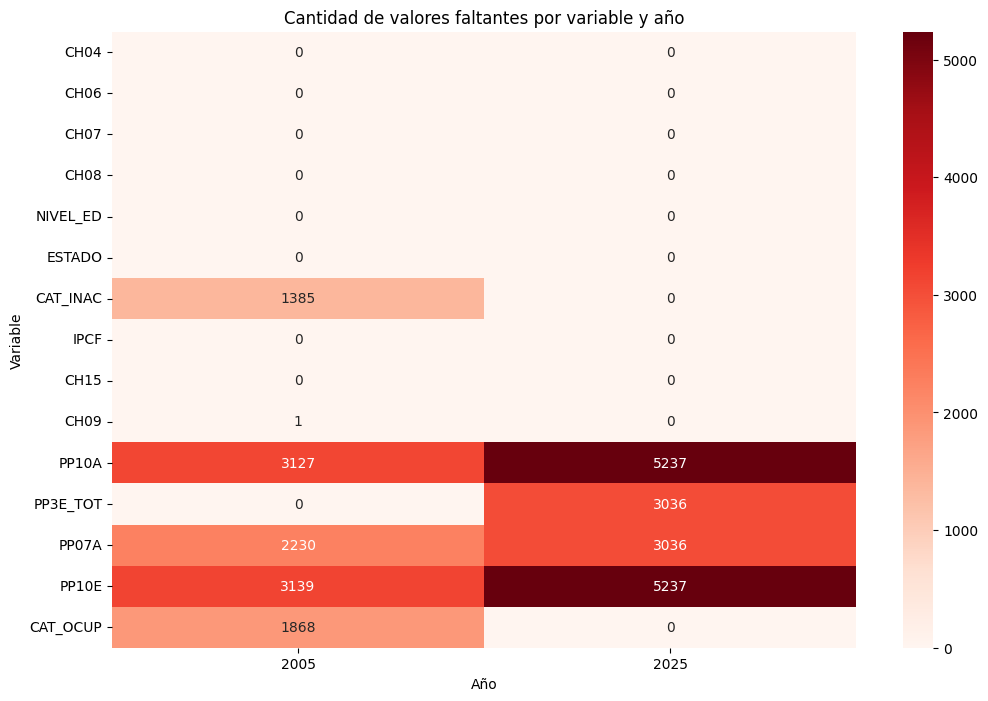

Top faltantes 2005:
 PP10E       3139
PP10A       3127
PP07A       2230
CAT_OCUP    1868
CAT_INAC    1385
Name: 2005, dtype: int64 

Top faltantes 2025:
 PP10A       5237
PP10E       5237
PP3E_TOT    3036
PP07A       3036
CH04           0
Name: 2025, dtype: int64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

missing_by_year = (
    df_05y25
      .groupby(year_col)[vars15]
      .apply(lambda g: g.isna().sum())
      .T
)

missing_by_year_H = missing_by_year.reindex(columns=[2005, 2025]).fillna(0).astype(int)

plt.figure(figsize=(12,8))
sns.heatmap(missing_by_year_H, annot=True, fmt="d", cmap="Reds")
plt.title("Cantidad de valores faltantes por variable y año")
plt.xlabel("Año")
plt.ylabel("Variable")
plt.show()

# Top para comentar en el informe
if 2005 in missing_by_year_H.columns:
    print("Top faltantes 2005:\n", missing_by_year_H[2005].sort_values(ascending=False).head(5), "\n")
if 2025 in missing_by_year_H.columns:
    print("Top faltantes 2025:\n", missing_by_year_H[2025].sort_values(ascending=False).head(5))


2c: Corregir variables si notan valores sin sentido (como ingresos negativos) de acuerdo a la documentación de la EPH (puede ser una codificación de no respuesta de los individuos) y eliminen estos valores extraños de sus 15 variables de interés. Comenten brevemente en el reporte dicho proceso de limpieza

In [ ]:
import pandas as pd
import numpy as np

df_clean = df_05y25.copy()

# --- 0) Convertir NUMÉRICAS a número (si venían como texto) ---
numericas = ["IPCF", "CH06"]
for col in numericas:
    if col in df_clean.columns:
        # intenta convertir a numérico; si hay texto raro -> NaN
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# --- 1) Ingresos: negativos -> NaN + conteo ---
ingresos_vars = [c for c in ["IPCF", "ITF", "P47T"] if c in df_clean.columns]
for var in ingresos_vars:
    count_before = (df_clean[var] < 0).sum()
    df_clean.loc[df_clean[var] < 0, var] = pd.NA
    print(f"{var}: {count_before} valores negativos recodificados como NaN")

# --- 2) Edad: fuera de rango -> NaN + conteo ---
if "CH06" in df_clean.columns:
    fuera_rango = ((df_clean["CH06"] < 0) | (df_clean["CH06"] > 100))
    count_before = fuera_rango.sum()
    df_clean.loc[fuera_rango, "CH06"] = pd.NA
    print(f"CH06 (edad): {count_before} valores fuera de rango recodificados como NaN")

# --- 3) Categóricas: no respuesta (98, 99) -> NaN + conteo ---
# contemplamos que a veces están como '98'/'99' (strings)
categoricas = ["CH07","CH08","NIVEL_ED","ESTADO","CAT_INAC","CAT_OCUP"]
for var in categoricas:
    if var in df_clean.columns:
        # normalizamos a numérico para poder detectar 98/99 aunque vengan como texto
        tmp = pd.to_numeric(df_clean[var], errors="coerce")
        mask = tmp.isin([98, 99])
        count_before = mask.sum()
        df_clean.loc[mask, var] = pd.NA
        print(f"{var}: {count_before} valores de no respuesta (98/99) recodificados como NaN")


IPCF: 0 valores negativos recodificados como NaN
CH06 (edad): 33 valores fuera de rango recodificados como NaN
CH07: 0 valores de no respuesta (98/99) recodificados como NaN
CH08: 0 valores de no respuesta (98/99) recodificados como NaN
NIVEL_ED: 0 valores de no respuesta (98/99) recodificados como NaN
ESTADO: 0 valores de no respuesta (98/99) recodificados como NaN
CAT_INAC: 0 valores de no respuesta (98/99) recodificados como NaN
CAT_OCUP: 0 valores de no respuesta (98/99) recodificados como NaN


In [ ]:
# df_clean es la base de datos que vamos a usar ahora con las 15 variables de interés, ya renombradas/limpiadas.

# PARTE II

In [ ]:
#muestra linea random de la base de datos
display(df_25.sample())
display(df_05.sample())



,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
7815,TQRMNOQYRHKOLOCDEFPCH00857189,2025,1,1,4,1,44,N,9,284,...,0,0,0,0,4.0,3.0,NaN,5.0,5.0,3.0


,CODUSU,nro_hogar,componente,h15,ano4,trimestre,region,mas_500,aglomerado,pondera,...,deccfr,ideccfr,rdeccfr,gdeccfr,pdeccfr,adeccfr,pj1_1,pj2_1,pj3_1,idimpp
36761,258390,1.0,2.0,Sí,2005.0,1er. Trimestre,43,N,Gran Paraná,206.0,...,03,04,03,,04,03,0.0,0.0,0.0,00000


3. Realicen un gráfico de barras mostrando la composición por sexo para
2005 y 2025 en su región. Comenten los resultados.

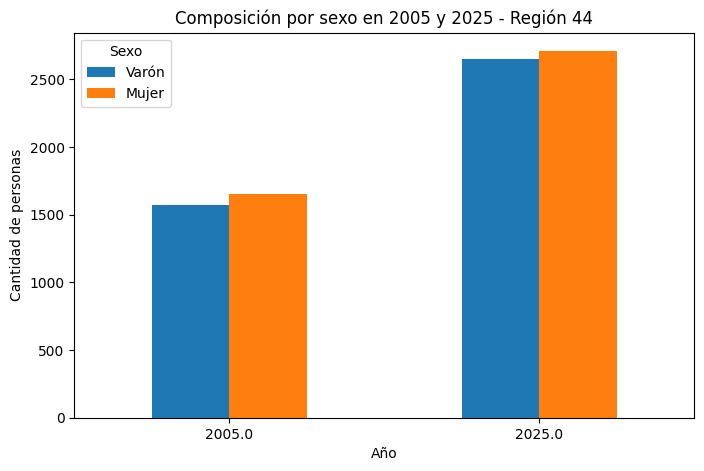

Tabla de composición por sexo en 2005 y 2025:
CH04    Varón  Mujer
ANO4                
2005.0   1575   1654
2025.0   2650   2709


In [ ]:
# Agrupar por año y sexo
conteo = df_clean.groupby(["ANO4", "CH04"]).size().reset_index(name="cantidad")

# Pivotear a formato ancho
tabla = conteo.pivot(index="ANO4", columns="CH04", values="cantidad").fillna(0)

# Renombrar columnas (1=Varón, 2=Mujer)
sexo_map = {1: "Varón", 2: "Mujer"}
tabla = tabla.rename(columns=sexo_map)

# Gráfico
tabla.plot(kind="bar", figsize=(8,5))
plt.title("Composición por sexo en 2005 y 2025 - Región 44")
plt.xlabel("Año")
plt.ylabel("Cantidad de personas")
plt.xticks(rotation=0)
plt.legend(title="Sexo")
plt.show()

# Mostrar tabla
print("Tabla de composición por sexo en 2005 y 2025:")
print(tabla)


4. Realicen una matriz de correlación para 2005 y 2025 con las
siguientes variables: CH04, CH06, CH07, CH08, NIVEL ED,
ESTADO, CAT_INAC, IPCF. Crear las variables dicotómicas binarias
necesarias (variables dummies) y renombrar dichas variables para
que las etiquetas tengan sentido en el gráfico de correlación. Utilicen
alguno de los comandos disponibles en este link para graficar la
matriz de correlación. Comenten los resultados.2

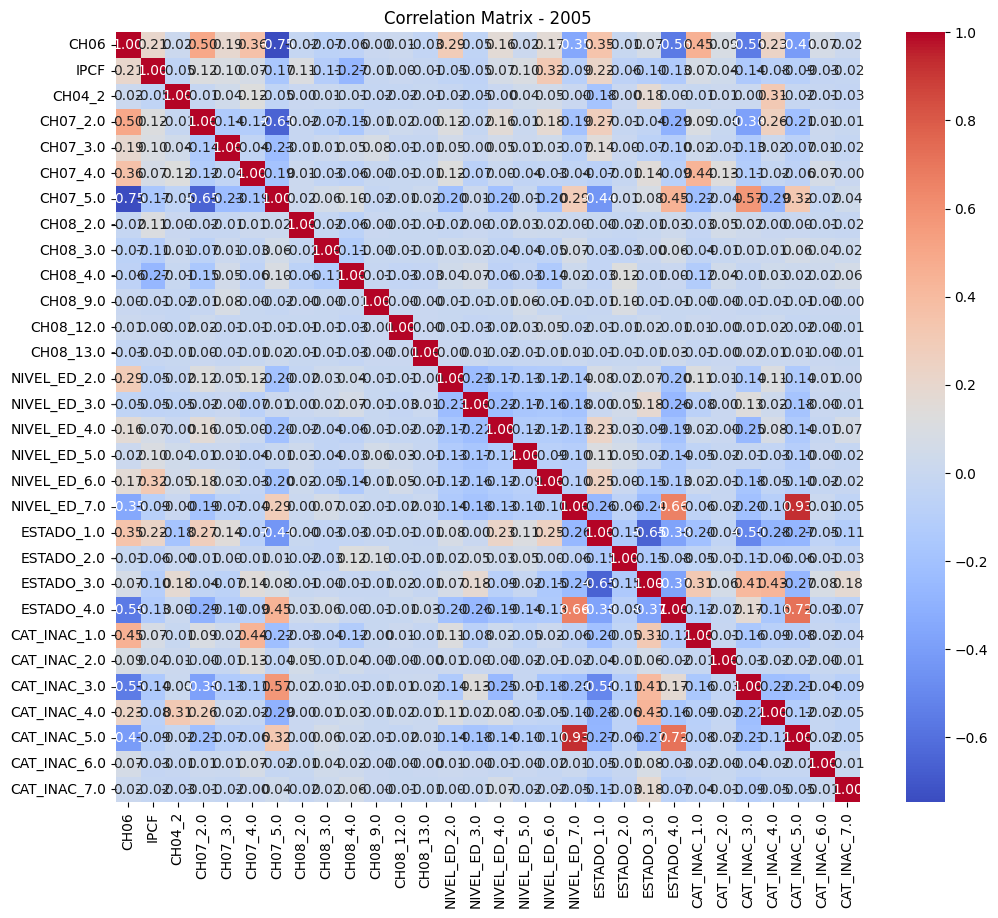

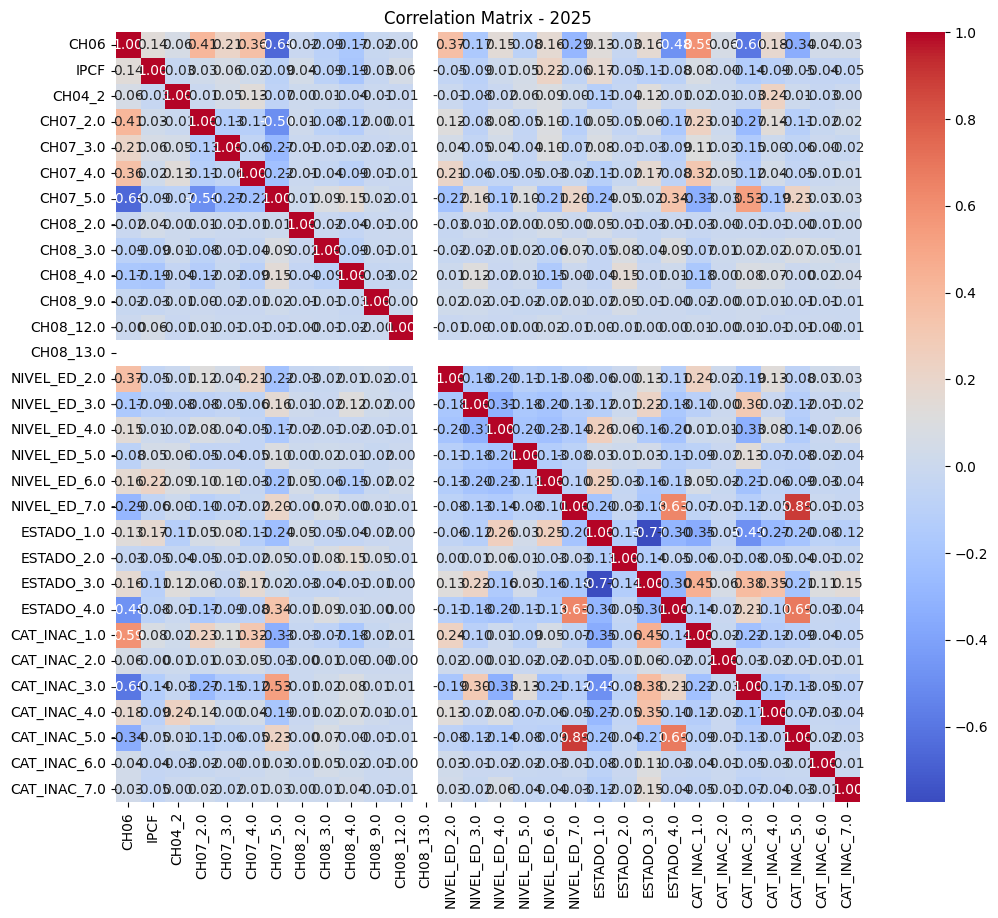

In [ ]:
# Select the relevant variables for the correlation matrix
correlation_vars = ["CH04", "CH06", "CH07", "CH08", "NIVEL_ED", "ESTADO", "CAT_INAC", "IPCF"]

# Create dummy variables for categorical columns, dropping the first category to avoid multicollinearity - CH06 y IPCF continuas
df_dummies = pd.get_dummies(df_clean[correlation_vars], columns=["CH04", "CH07", "CH08", "NIVEL_ED", "ESTADO", "CAT_INAC"], drop_first=True)

# Split the data by year
df_2005 = df_dummies[df_clean["ANO4"] == 2005.0]
df_2025 = df_dummies[df_clean["ANO4"] == 2025.0]

# Calculate the correlation matrix for each year
corr_matrix_2005 = df_2005.corr()
corr_matrix_2025 = df_2025.corr()

# Visualize the correlation matrices
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_2005, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - 2005")
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_2025, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - 2025")
plt.show()

# PARTE 3: Conociendo a los pobres y no pobres


Los siguientes incisos apuntan a ver los resultados para su región
seleccionada y comparando 2005 con 2025.


5. Uno de los grandes problemas de la EPH es la creciente cantidad de
hogares que no reportan sus ingresos (ver por ejemplo el siguiente
informe). ¿Cuántas personas no respondieron cuál es su condición de
actividad? Guarden como una base distinta llamada respondieron
las observaciones donde respondieron la pregunta sobre su ingreso
total familiar (ITF). Las observaciones con ITF=0 guárdenlas en una
base bajo el nombre norespondieron.

In [ ]:
import pandas as pd

# Asegurar que ESTADO sea numérico (si quedó como texto "0", lo convierte)
df_05y25["ESTADO"] = pd.to_numeric(df_05y25["ESTADO"], errors="coerce")

# Ver si aparecen 0 o NaN
print("¿Hay 0 en ESTADO? ", (df_05y25["ESTADO"] == 0).any())
print("¿Hay NaN en ESTADO?", df_05y25["ESTADO"].isna().any())

# Conteo total de no respuesta (0 o NaN)
mask_no_resp = df_05y25["ESTADO"].isna() | (df_05y25["ESTADO"] == 0)
n_total = len(df_05y25)
n_no    = mask_no_resp.sum()
print(f"\nNo respondieron condición de actividad (0 o NaN): {n_no} de {n_total}  ({n_no/n_total:.1%})")

# Detalle por año
if "ANO4" in df_05y25.columns:
    resumen = (df_05y25.assign(no_resp=mask_no_resp)
                          .groupby("ANO4")["no_resp"]
                          .agg(no_resp="sum", total="size"))
    resumen["pct"] = 100 * resumen["no_resp"] / resumen["total"]
    print("\nPor año (2005 vs 2025):\n", resumen)


print(df_05y25["ESTADO"].value_counts(dropna=False).sort_index()) # Mirar los valores que tiene ESTADO


¿Hay 0 en ESTADO?  True
¿Hay NaN en ESTADO? False

No respondieron condición de actividad (0 o NaN): 13 de 8588  (0.2%)

Por año (2005 vs 2025):
         no_resp  total       pct
ANO4                            
2005.0        2   3229  0.061939
2025.0       11   5359  0.205262
ESTADO
0      13
1    3604
2     224
3    3625
4    1122
Name: count, dtype: int64


In [ ]:
#ahora voy con la segunda parte: veo que onda la variable ITF en los df de cada año ya filtrados
vals_ITF05 = df_05_pat["ITF"].unique()
print("valores de ITF 2005:", vals_ITF05)

valores de ITF 2005: [ 2400.   300.   830.   700.  2624.  1730.  3300.  2150.  3100.  1000.
     0.  4000.  1450.  1400.  6100.  4350.   500.   800.   650.  1500.
  1200.  2200.   243.  1920.  2490.   600.  1950.  1990.  2800.  4220.
   360.   100.  1050.  5000.  3050.  3900.  3500.  1585.   845.  2000.
   900.  1900.  2300.  1800.  1220.  3055.  5100.   470.  2770.   810.
   750.  8100.  2690.   580.   400.   690.  1100.  1750.   350.  4300.
   250.  2650.  2900.  3400.  2250.   928.  6000.  2100.  1511.  4070.
   525.  2500.   450.  2850.   575.  3150.  2350.  1330.   740.  3810.
  6270.  2305.  1380.  1520.   405.  1160. 11000.   570.  2020. 10438.
  3800.  4100.   910.  1700.   335.  5760.   200.  7100.    50.  1780.
   140.  2520.  1480.  1650.  3000.  5400.  3200.  1720.   150.  1725.
  1593.  1580.  2600.   871.  2340.   880. 10000.  1300.  1600.  2645.
   970.  1830.  9800.  1290.   945.   775.  1850.   950.   430.  3700.
  2932.  1350.  2700.  2140.  1010.   749.    20.  7500.

In [ ]:

# Create a new dataframe df_2005_2 with 'ITF' column from df_05_pat
df_2005_2 = df_05int.copy()
df_2005_2['ITF'] = df_05_pat['ITF']
df_2005_2.sample(10)

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH15,CH09,PP10A,PP3E_TOT,PP07A,PP10E,CAT_OCUP,ANO4,ITF
45232,1,20.0,5.0,4.0,1,3,6.0,83.333333,1.0,2.0,NaN,0.0,NaN,NaN,NaN,2005.0,500.0
44185,1,11.0,5.0,4.0,1,3,3.0,92.500000,1.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0,740.0
46919,1,17.0,5.0,1.0,4,3,7.0,560.000000,1.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0,2800.0
46136,2,73.0,3.0,3.0,2,3,4.0,800.000000,3.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0,800.0
46985,1,11.0,5.0,4.0,1,3,3.0,300.000000,3.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0,1500.0
44018,1,Menos de 1 año,5.0,4.0,7,4,5.0,112.500000,1.0,3.0,NaN,0.0,NaN,NaN,NaN,2005.0,900.0
45790,1,23.0,5.0,4.0,5,3,7.0,1200.000000,1.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0,3600.0
44636,2,30.0,2.0,4.0,6,2,NaN,700.000000,3.0,1.0,1.0,0.0,NaN,1.0,3.0,2005.0,2100.0
43893,2,6.0,5.0,4.0,1,4,3.0,440.000000,1.0,2.0,NaN,0.0,NaN,NaN,NaN,2005.0,2200.0
44914,1,6.0,5.0,1.0,1,4,3.0,175.000000,1.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0,700.0


In [ ]:
# Create a new dataframe df_2025_2 with 'ITF' column from df_25_pat
df_2025_2 = df_25int.copy()
df_2025_2['ITF'] = df_25_pat['ITF']

df_2025_2.sample(10)

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH15,CH09,PP10A,PP3E_TOT,PP07A,PP10E,CAT_OCUP,ANO4,ITF
43740,1,17,5,4.0,3,3,3,315000.00,1,1,NaN,NaN,NaN,NaN,0,2025,1260000
162,2,5,5,1.0,1,4,5,1433333.33,1,1,NaN,NaN,NaN,NaN,0,2025,4300000
16578,1,54,2,1.0,2,1,0,0.00,3,1,NaN,56.0,0.0,NaN,2,2025,0
22464,1,26,5,4.0,4,1,0,155000.00,3,1,NaN,40.0,1.0,NaN,3,2025,620000
16529,1,15,5,1.0,3,3,3,176000.00,1,1,NaN,NaN,NaN,NaN,0,2025,528000
21224,2,63,4,1.0,3,1,0,550000.00,1,1,NaN,24.0,0.0,NaN,2,2025,1100000
1290,2,58,5,1.0,2,3,7,0.00,1,1,NaN,NaN,NaN,NaN,0,2025,0
21024,1,28,2,1.0,6,1,0,700000.00,1,1,NaN,30.0,5.0,NaN,3,2025,2100000
5828,2,16,5,4.0,3,3,3,76000.00,1,1,NaN,NaN,NaN,NaN,0,2025,380000
11299,1,9,5,1.0,1,4,3,473333.33,1,1,NaN,NaN,NaN,NaN,0,2025,1420000


In [ ]:

# Asegurar numérico
df_2005_2["ITF"] = pd.to_numeric(df_2005_2["ITF"], errors="coerce")
df_2025_2["ITF"] = pd.to_numeric(df_2025_2["ITF"], errors="coerce")


# Unir ambas bases ===
df_itf_act = pd.concat([df_2005_2, df_2025_2], ignore_index=True)

# respondieron ITF (1 si ITF>0 y no NaN; 0 si ITF==0 o NaN) ===
df_itf_act["respondio_ITF"] = np.where(df_itf_act["ITF"].notna() & (df_itf_act["ITF"] > 0), 1, 0).astype("int8")

#  Bases pedidas por consigna ===
respondieron  = df_itf_act.query("respondio_ITF == 1").copy()
norespondieron = df_itf_act.query("respondio_ITF == 0").copy()

# === Resúmenes útiles para el informe ===
# Respondieron vs no respondieron por año
resumen_itf = (
    df_itf_act.groupby(["ANO4","respondio_ITF"]).size()
      .unstack(fill_value=0)
      .rename(columns={0:"norespondieron_ITF", 1:"respondieron_ITF"})
      .reset_index()
)
resumen_itf["tasa_noresp"] = resumen_itf["norespondieron_ITF"] / (
    resumen_itf["norespondieron_ITF"] + resumen_itf["respondieron_ITF"]
)


print("Resumen ITF por año:")
print(resumen_itf)



Resumen ITF por año:
respondio_ITF    ANO4  norespondieron_ITF  respondieron_ITF  tasa_noresp
0              2005.0                  23              3206     0.007123
1              2025.0                1202              4157     0.224296


In [ ]:
respondieron.sample(10)

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH15,CH09,PP10A,PP3E_TOT,PP07A,PP10E,CAT_OCUP,ANO4,ITF,respondio_ITF
8431,1,14,5.0,4.0,3,3,3.0,1.633333e+05,1.0,1.0,NaN,NaN,NaN,NaN,0.0,2025.0,490000.0,1
8444,1,64,4.0,1.0,6,3,1.0,5.000000e+05,3.0,1.0,NaN,NaN,NaN,NaN,0.0,2025.0,500000.0,1
2213,1,5.0,5.0,1.0,7,4,5.0,6.100000e+02,1.0,2.0,NaN,0.0,NaN,NaN,NaN,2005.0,1830.0,1
7465,2,45,2.0,1.0,3,1,0.0,1.020000e+06,3.0,1.0,NaN,0.0,6.0,NaN,3.0,2025.0,4080000.0,1
2087,1,28.0,2.0,1.0,4,1,NaN,2.900000e+02,3.0,1.0,NaN,0.0,6.0,NaN,3.0,2005.0,1160.0,1
7929,2,39,5.0,1.0,6,1,0.0,1.250000e+06,3.0,1.0,NaN,45.0,6.0,NaN,3.0,2025.0,2500000.0,1
1894,1,3.0,5.0,1.0,7,4,5.0,1.500000e+02,3.0,2.0,NaN,0.0,NaN,NaN,NaN,2005.0,450.0,1
561,2,19.0,1.0,1.0,4,3,4.0,3.800000e+02,3.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0,1900.0,1
6351,2,24,1.0,4.0,4,1,0.0,3.300000e+05,1.0,1.0,NaN,24.0,5.0,NaN,3.0,2025.0,1320000.0,1
2317,2,25.0,5.0,3.0,3,3,7.0,1.785714e+02,1.0,1.0,NaN,0.0,NaN,NaN,NaN,2005.0,1250.0,1


In [ ]:
norespondieron.sample(10)

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH15,CH09,PP10A,PP3E_TOT,PP07A,PP10E,CAT_OCUP,ANO4,ITF,respondio_ITF
7040,2,22,5.0,4.0,5,3,3.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,2025.0,0.0,0
7595,1,44,2.0,1.0,2,1,0.0,0.0,3.0,1.0,NaN,30.0,0.0,NaN,2.0,2025.0,0.0,0
3369,1,9,5.0,1.0,1,4,3.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,2025.0,0.0,0
3944,2,47,2.0,1.0,6,1,0.0,0.0,1.0,1.0,NaN,45.0,6.0,NaN,3.0,2025.0,0.0,0
8138,2,62,2.0,1.0,3,3,4.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,2025.0,0.0,0
5738,1,12,5.0,1.0,3,3,3.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,2025.0,0.0,0
5624,1,71,2.0,1.0,1,1,0.0,0.0,1.0,1.0,NaN,10.0,0.0,NaN,2.0,2025.0,0.0,0
7659,2,61,4.0,1.0,6,1,0.0,0.0,3.0,1.0,NaN,0.0,6.0,NaN,3.0,2025.0,0.0,0
6253,2,19,5.0,1.0,5,3,3.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,2025.0,0.0,0
6996,2,7,5.0,1.0,1,4,3.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,2025.0,0.0,0


6) Utilizando el archivo tabla_adulto_equiv.xlsx, agreguen a su base
de datos una columna llamada adulto_equiv que contenga los
valores de adulto equivalente de cada persona según su sexo y edad
(por ejemplo, a un varón de 2 años le corresponde 0.46). Finalmente,
con el comando groupby sumen esta nueva columna para las
personas que pertenecen a un mismo hogar y guarden ese dato en una
columna llamada ad_equiv_hogar3
.

In [ ]:
#importo tabla adulto equivalente
from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]

adulto_equiv = pd.read_excel(fname)
adulto_equiv

Saving tabla_adulto_equiv.xlsx to tabla_adulto_equiv.xlsx


,"Tabla de equivalencias de necesidades energéticas. Unidades de adulto equivalente, según sexo y edad",Unnamed: 1,Unnamed: 2
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,Edad,Mujeres,Varones
3,NaN,NaN,NaN
4,Menor de 1 año,0.35,0.35
5,1año,0.37,0.37
6,2 años,0.46,0.46
7,3 años,0.51,0.51
8,4 años,0.55,0.55
9,5 años,0.6,0.6


In [ ]:
import pandas as pd
import numpy as np

def cargar_tabla_adulto_equiv_simple(path="tabla_adulto_equiv.xlsx", verbose=True):
    # Leer todo como string para no “romper” nada al principio
    raw = pd.read_excel(path, header=None, dtype=str)

    # 1) Detectar automáticamente la fila y las 3 columnas correctas: Edad | Mujeres | Varones
    hdr_row = None
    col_edad = col_muj = col_var = None
    for r in range(len(raw)):
        row = raw.iloc[r].astype(str).str.strip().str.lower()
        for c in range(len(row) - 2):
            a, b, d = row.iloc[c], row.iloc[c+1], row.iloc[c+2]
            if a == "edad" and "mujer" in b and ("varon" in d or "varón" in d):
                hdr_row, col_edad, col_muj, col_var = r, c, c+1, c+2
                break
        if hdr_row is not None:
            break

    if hdr_row is None:
        raise ValueError("No encontré encabezados 'Edad | Mujeres | Varones' en el archivo.")

    if verbose:
        print(f"Encabezado detectado en fila {hdr_row} | columnas: EDAD={col_edad}, MUJERES={col_muj}, VARONES={col_var}")

    # 2) Quedarnos con esas 3 columnas desde la fila siguiente
    tbl = raw.iloc[hdr_row+1:, [col_edad, col_muj, col_var]].copy()
    tbl.columns = ["EDAD", "MUJERES", "VARONES"]

    # 3) Limpiar EDAD (espacios raros) y pasar equivalencias a número (coma -> punto)
    tbl["EDAD"] = (tbl["EDAD"].fillna("")
                             .str.replace("\xa0", " ", regex=False)
                             .str.strip()
                             .str.replace(r"\s+", " ", regex=True))

    for c in ["MUJERES", "VARONES"]:
        s = tbl[c].fillna("").str.replace("\xa0", " ", regex=False).str.strip()
        s = s.str.replace(",", ".", regex=False)  # por si vienen con coma decimal
        tbl[c] = pd.to_numeric(s, errors="coerce")

    # 4) Quitar filas basura (todas NaN o textos tipo 'Ejemplos...', 'Fuente...')
    basura = tbl["EDAD"].str.lower().str.contains("ejemplo|fuente|indec", na=False)
    todo_nan = tbl[["MUJERES","VARONES"]].isna().all(axis=1)
    tbl = tbl[~(basura | todo_nan)].reset_index(drop=True)

    return tbl

# === USO ===
adulto_equiv = cargar_tabla_adulto_equiv_simple("tabla_adulto_equiv.xlsx")

# 1) quitar la cabecera repetida
mask_midheader = adulto_equiv["EDAD"].astype(str).str.strip().str.lower().eq("edad")

# 2) quitar filas “basura” donde MUJERES y VARONES son ambos NaN
mask_allnan = adulto_equiv[["MUJERES","VARONES"]].isna().all(axis=1)

adulto_equiv = adulto_equiv[~(mask_midheader | mask_allnan)].reset_index(drop=True)

print(adulto_equiv)





Encabezado detectado en fila 3 | columnas: EDAD=0, MUJERES=1, VARONES=2
              EDAD  MUJERES  VARONES
0   Menor de 1 año     0.35     0.35
1             1año     0.37     0.37
2           2 años     0.46     0.46
3           3 años     0.51     0.51
4           4 años     0.55     0.55
5           5 años     0.60     0.60
6           6 años     0.64     0.64
7           7 años     0.66     0.66
8           8 años     0.68     0.68
9           9 años     0.69     0.69
10         10 años     0.70     0.79
11         11 años     0.72     0.82
12         12 años     0.74     0.85
13         13 años     0.76     0.90
14         14 años     0.76     0.96
15         15 años     0.77     1.00
16         16 años     0.77     1.03
17         17 años     0.77     1.04
18    18 a 29 años     0.76     1.02
19    30 a 45 años     0.77     1.00
20    46 a 60 años     0.76     1.00
21    61 a 75 años     0.67     0.83
22  más de 75 años     0.63     0.74


In [ ]:
# Merge df_itf_act with adulto_equiv to get the 'adulto_equiv' value for each person
# Need to prepare adulto_equiv for merging by creating age ranges and mapping sex codes
def map_age_to_range(age):
    # Ensure age is treated as numeric, handle potential NaNs or conversion errors
    if pd.isna(age):
        return np.nan
    try:
        age = int(age)
    except ValueError:
        return np.nan # Handle cases where conversion to int fails

    if age < 1:
        return "Menor de 1 año"
    elif age == 1:
        return "1año"
    elif age == 2:
        return "2 años"
    elif age == 3:
        return "3 años"
    elif age == 4:
        return "4 años"
    elif age == 5:
        return "5 años"
    elif age == 6:
        return "6 años"
    elif age == 7:
        return "7 años"
    elif age == 8:
        return "8 años"
    elif age == 9:
        return "9 años"
    elif age == 10:
        return "10 años"
    elif age == 11:
        return "11 años"
    elif age == 12:
        return "12 años"
    elif age == 13:
        return "13 años"
    elif age == 14:
        return "14 años"
    elif age == 15:
        return "15 años"
    elif age == 16:
        return "16 años"
    elif age == 17:
        return "17 años"
    elif 18 <= age <= 29:
        return "18 a 29 años"
    elif 30 <= age <= 45:
        return "30 a 45 años"
    elif 46 <= age <= 60:
        return "46 a 60 años"
    elif 61 <= age <= 75:
        return "61 a 75 años"
    elif age > 75:
        return "más de 75 años"
    else:
        return np.nan

# Ensure CH06 is numeric
df_itf_act['CH06'] = pd.to_numeric(df_itf_act['CH06'], errors='coerce')

df_itf_act['EDAD_RANGO'] = df_itf_act['CH06'].apply(map_age_to_range)

# Map sex codes to column names in adulto_equiv
df_itf_act['SEXO_COL'] = df_itf_act['CH04'].map({1: 'VARONES', 2: 'MUJERES'})

# Merge to get the adulto_equiv value
df_itf_act = pd.merge(df_itf_act, adulto_equiv, left_on='EDAD_RANGO', right_on='EDAD', how='left')

# Select the correct adulto_equiv value based on sex
df_itf_act['adulto_equiv'] = df_itf_act.apply(lambda row: row[row['SEXO_COL']] if pd.notna(row['SEXO_COL']) and pd.notna(row['EDAD_RANGO']) else np.nan, axis=1)

# Drop the intermediate columns used for merging
df_itf_act = df_itf_act.drop(columns=['EDAD_RANGO', 'SEXO_COL', 'EDAD', 'MUJERES', 'VARONES'])

# Add 'CODUSU' y "NRO_HOGAR" column back to df_itf_act
df_itf_act['CODUSU'] = pd.concat([df_05_pat['CODUSU'], df_25_pat['CODUSU']], ignore_index=True)
df_itf_act['NRO_HOGAR'] = pd.concat([df_05_pat['NRO_HOGAR'], df_25_pat['NRO_HOGAR']], ignore_index=True)

# Recalcular adultos equivalentes por hogar (usa ambas llaves)
df_itf_act["ad_equiv_hogar"] = (
    df_itf_act
    .groupby(["CODUSU", "NRO_HOGAR"])["adulto_equiv"]
    .transform("sum")
)


# Chequeo rápido
print(df_itf_act[["CODUSU","NRO_HOGAR","adulto_equiv","ad_equiv_hogar"]].head())


display(df_itf_act.head())


     CODUSU  NRO_HOGAR  adulto_equiv  ad_equiv_hogar
0  125814          1.0          1.00            3.93
1  125814          1.0          0.77            3.93
2  125814          1.0          0.96            3.93
3  125814          1.0          0.69            3.93
4  125814          1.0          0.51            3.93


,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH15,CH09,...,PP07A,PP10E,CAT_OCUP,ANO4,ITF,respondio_ITF,adulto_equiv,CODUSU,NRO_HOGAR,ad_equiv_hogar
0,1,46.0,2.0,1.0,3,1,NaN,480.0,3.0,1.0,...,6.0,NaN,3.0,2005.0,2400.0,1,1.00,125814,1.0,3.93
1,2,32.0,2.0,1.0,3,3,4.0,480.0,3.0,1.0,...,NaN,NaN,NaN,2005.0,2400.0,1,0.77,125814,1.0,3.93
2,1,14.0,5.0,1.0,2,3,3.0,480.0,3.0,1.0,...,NaN,NaN,NaN,2005.0,2400.0,1,0.96,125814,1.0,3.93
3,1,9.0,5.0,1.0,1,4,3.0,480.0,1.0,1.0,...,NaN,NaN,NaN,2005.0,2400.0,1,0.69,125814,1.0,3.93
4,2,3.0,5.0,1.0,7,4,5.0,480.0,1.0,2.0,...,NaN,NaN,NaN,2005.0,2400.0,1,0.51,125814,1.0,3.93


In [ ]:
#Finalmente,con el comando groupby sumen esta nueva columna para las personas que pertenecen a un mismo hogar y guarden ese dato en una columna llamada ad_equiv_hogar3.


In [ ]:
display(df_itf_act[['CODUSU', 'adulto_equiv', 'ad_equiv_hogar']].head())

,CODUSU,adulto_equiv,ad_equiv_hogar
0,125814,1.00,3.93
1,125814,0.77,3.93
2,125814,0.96,3.93
3,125814,0.69,3.93
4,125814,0.51,3.93


In [ ]:
#chequeamos
display(df_itf_act.sample(5))

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH15,CH09,...,PP07A,PP10E,CAT_OCUP,ANO4,ITF,respondio_ITF,adulto_equiv,CODUSU,NRO_HOGAR,ad_equiv_hogar
5129,2,44.0,1.0,1.0,4,1,0.0,0.0,2.0,1.0,...,6.0,NaN,3.0,2025.0,0.0,0,0.77,TQRMNOUXXHLKKNCDEGNFJ00853309,1.0,2.45
1885,2,43.0,5.0,1.0,5,1,NaN,296.0,3.0,1.0,...,5.0,NaN,3.0,2005.0,1480.0,1,0.77,178968,2.0,3.68
4776,2,48.0,1.0,1.0,6,3,4.0,106750.0,3.0,1.0,...,NaN,NaN,0.0,2025.0,427000.0,1,0.76,TQRMNOPUUHMKKPCDEHGHJ00879030,1.0,3.02
217,1,NaN,5.0,4.0,7,4,5.0,112.5,1.0,3.0,...,NaN,NaN,NaN,2005.0,900.0,1,NaN,166264,2.0,5.43
3770,2,19.0,5.0,4.0,5,3,3.0,326000.0,3.0,1.0,...,NaN,NaN,0.0,2025.0,326000.0,1,0.76,TQRMNOQRRHJMLNCDEOHCH00877328,1.0,0.76


7. Sabiendo que la Canasta Básica Total para un adulto equivalente en
el primer trimestre de 2025 es aproximadamente $365.177, agreguen
a la base respondieron una columna llamada
ingreso_necesario que sea el producto de este valor por
ad_equiv_hogar. Para el primer trimestre de 2005 la Canasta
Básica Total para un adulto equivalente era aproximadamente
$205,07. Note que este es el valor mínimo que necesita ese hogar para
no ser pobre.

In [ ]:

# Ingreso necesario = CBA adulto equivalente del año × adultos equivalentes del hogar

import numpy as np
import pandas as pd

# 1) Asegurar tipos numéricos por si acaso
for col in ["ITF", "ad_equiv_hogar", "ANO4"]:
    if col in df_itf_act.columns:
        df_itf_act[col] = pd.to_numeric(df_itf_act[col], errors="coerce")

# 2) (Re)construyo 'respondieron' a partir de df_itf_act para asegurar que traiga 'ad_equiv_hogar'
#    (si ya existe 'respondieron', lo pisa con esta versión "completa")
cols_base = ["ANO4", "TRIMESTRE", "CODUSU", "ITF", "ad_equiv_hogar"]
cols_existentes = [c for c in cols_base if c in df_itf_act.columns]

respondieron = (
    df_itf_act.loc[df_itf_act["respondio_ITF"] == 1, cols_existentes]
               .copy()
)

# 3) Mapeo CBA por adulto equivalente según año (primer trimestre)
CBA_por_adulto = {
    2005: 205.07,   # pesos 2005 T1, según consigna
    2025: 365_177.0 # pesos 2025 T1, según consigna
}

# 4) Calculo ingreso_necesario = CBA_adulto_equiv * ad_equiv_hogar
respondieron["CBA_adulto_equiv"] = respondieron["ANO4"].map(CBA_por_adulto)
respondieron["ingreso_necesario"] = respondieron["CBA_adulto_equiv"] * respondieron["ad_equiv_hogar"]

# 5) Chequeos rápidos
print("Resumen de 'ad_equiv_hogar' en respondieron:")
print(respondieron["ad_equiv_hogar"].describe())

print("\nCBA por adulto equivalente aplicada por año:")
print(respondieron.groupby("ANO4")["CBA_adulto_equiv"].first())

print("\nVista rápida (ANO4, CODUSU, ITF, ad_equiv_hogar, ingreso_necesario):")
display(respondieron[["ANO4","CODUSU","ITF","ad_equiv_hogar","ingreso_necesario"]].head())


Resumen de 'ad_equiv_hogar' en respondieron:
count    7363.000000
mean        3.035428
std         1.501756
min         0.630000
25%         1.780000
50%         2.820000
75%         3.800000
max         9.880000
Name: ad_equiv_hogar, dtype: float64

CBA por adulto equivalente aplicada por año:
ANO4
2005.0       205.07
2025.0    365177.00
Name: CBA_adulto_equiv, dtype: float64

Vista rápida (ANO4, CODUSU, ITF, ad_equiv_hogar, ingreso_necesario):


,ANO4,CODUSU,ITF,ad_equiv_hogar,ingreso_necesario
0,2005.0,125814,2400.0,3.93,805.9251
1,2005.0,125814,2400.0,3.93,805.9251
2,2005.0,125814,2400.0,3.93,805.9251
3,2005.0,125814,2400.0,3.93,805.9251
4,2005.0,125814,2400.0,3.93,805.9251


8. Por último, agreguen a respondieron una columna llamada pobre
que tome valor 1 si el ITF es menor al ingreso necesario que necesita
esa familia, y 0 en caso contrario. ¿Cuántos pobres identificaron para
cada año? ¿Qué porcentaje de la muestra representa?

In [ ]:
# === Inciso 8 — Resumen "intuitivo" como la referencia ===
import pandas as pd
import numpy as np

# 0) Tomo la fuente preferida si existe
df = globals().get("respondieron_p8",
      globals().get("respondieron_p7",
      globals().get("respondieron")))
if df is None:
    raise ValueError("No encuentro respondieron/respondieron_p7/respondieron_p8. Corré antes los incisos 7–8.")

df = df.copy()

# 1) Detecto columna de año y la muestro como 'ANIO' (solo estética)
year_col = "ANIO" if "ANIO" in df.columns else ("ANO4" if "ANO4" in df.columns else None)
if year_col is None:
    raise ValueError("No encuentro ni 'ANIO' ni 'ANO4' para agrupar por año.")
df["ANIO"] = df[year_col]

# 2) Creo 'pobre' si no existe (NA cuando no se puede comparar)
if "pobre" not in df.columns:
    if "ITF" not in df.columns or "ingreso_necesario" not in df.columns:
        raise ValueError("Faltan 'ITF' o 'ingreso_necesario' para calcular 'pobre'. Corré el inciso 7 primero.")
    df["ITF"] = pd.to_numeric(df["ITF"], errors="coerce")
    df["ingreso_necesario"] = pd.to_numeric(df["ingreso_necesario"], errors="coerce")
    valid = df["ITF"].notna() & df["ingreso_necesario"].notna()
    df["pobre"] = pd.NA
    df.loc[valid, "pobre"] = (df.loc[valid, "ITF"] < df.loc[valid, "ingreso_necesario"]).astype("int8")
    df["pobre"] = df["pobre"].astype("Int64")

# 3) Construyo las métricas
grp = df.groupby("ANIO")
pobres = grp["pobre"].sum(min_count=1).rename("pobres")                      # suma de 1s (ignora NA)
den_valid = grp["pobre"].apply(lambda s: s.notna().sum()).rename("den_valid")# comparables
n_total = grp.size().rename("n_filas_total")                                 # total filas en la base

tabla = pd.concat([pobres, den_valid, n_total], axis=1)
tabla["% sobre válidos"] = (tabla["pobres"] / tabla["den_valid"] * 100).round(1)
tabla.index.name = "ANIO"

print("──── Inciso 8: Pobres identificados por año ────")
display(tabla)

# 4) % sobre total muestral (en bloque aparte, como en tu captura)
porc_total = ((tabla["pobres"] / tabla["n_filas_total"]) * 100).round(1)
porc_total.name = "% sobre total muestral"
porc_total.index.name = "ANIO"

print("\n% sobre total muestral")
display(porc_total.to_frame())


──── Inciso 8: Pobres identificados por año ────


,pobres,den_valid,n_filas_total,% sobre válidos
ANIO,,,,
2005.0,570,3206,3206,17.8
2025.0,865,4157,4157,20.8



% sobre total muestral


,% sobre total muestral
ANIO,
2005.0,17.8
2025.0,20.8


In [ ]:
# den_valid: cuántas personas tienen los dos datos que necesito para decidir si son pobres:

In [ ]:
#Resultados:
# 2005: 574 personas pobres sobre 3.206 comparables ⇒ 17,9%.
# 2025: 867 personas pobres sobre 4.157 comparables ⇒ 20,9%.
#La incidencia de pobreza por persona sube ~3 puntos entre 2005 y 2025 en tu muestra.

9. Muestren estadísticas descriptivas relevantes de pobre en una tabla,
comparando 2005 con 2025. Además, hagan 2 gráficos exploratorios a
elección usando la variable pobre. Comenten. tulo

In [ ]:
df.sample()

,ANO4,CODUSU,ITF,ad_equiv_hogar,CBA_adulto_equiv,ingreso_necesario,ANIO,pobre
6058,2025.0,TQRMNOQTYHJMKQCDEOHCH00876296,1650000.0,3.34,365177.0,1219691.18,2025.0,0


In [ ]:
#TABLA DESCRIPTIVA de pobre

# Calculamos estadísticas descriptivas para cada año
stats = df.groupby("ANIO")["pobre"].agg(
    media = "mean",           # % de pobres
    desvio_std = "std",       # desvío estándar
    mediana = "median",       # mediana
    N = "count"               # número de casos
).reset_index()

# Convertir la media en porcentaje
stats["media"] = stats["media"] * 100

print(stats)


     ANIO      media  desvio_std  mediana     N
0  2005.0  17.779164    0.382397      0.0  3206
1  2025.0  20.808275    0.405985      0.0  4157


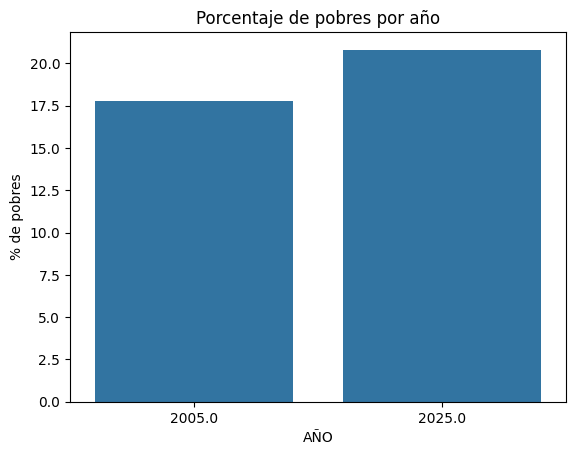

In [ ]:
#GRAFICO 1: barras comparando años
import seaborn as sns
import matplotlib.pyplot as plt

prop = df.groupby("ANIO")["pobre"].mean().reset_index()
prop["pobre"] = prop["pobre"] * 100

sns.barplot(data=prop, x="ANIO", y="pobre")
plt.ylabel("% de pobres")
plt.xlabel("AÑO")
plt.title("Porcentaje de pobres por año")
plt.show()


In [ ]:
## GRAFICO 2
# Asegurar tipos
for c in ["ITF","ingreso_necesario","ad_equiv_hogar"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# (A) IPCF y umbral "por adulto equivalente" (debería ser constante por año)
df["IPCF"] = df["ITF"] / df["ad_equiv_hogar"]
df["umbral_equiv"] = df["ingreso_necesario"] / df["ad_equiv_hogar"]

# (B) Ver mediana por grupo y año (esto NO debería dar que pobres > no pobres)
print(df.groupby(["ANIO","pobre"])["IPCF"].median())

# (C) ¿Hay no pobres por debajo del umbral? (no debería)
mask_incons = (df["pobre"]==0) & (df["IPCF"] < df["umbral_equiv"])
print("No pobres por debajo del umbral:", mask_incons.sum())

# (D) ¿Hay pobres por encima del umbral? (puede haber casos pegados si usaste < y no <=)
mask_incons2 = (df["pobre"]==1) & (df["IPCF"] >= df["umbral_equiv"])
print("Pobres por encima del umbral:", mask_incons2.sum())

# (E) Chequear NA o ceros en el denominador
print("NA en ad_equiv_hogar:", df["ad_equiv_hogar"].isna().sum())
print("Ceros en ad_equiv_hogar:", (df["ad_equiv_hogar"]==0).sum())


ANIO    pobre
2005.0  0           614.406780
        1           135.581062
2025.0  0        809352.517986
        1        256211.180124
Name: IPCF, dtype: float64
No pobres por debajo del umbral: 0
Pobres por encima del umbral: 0
NA en ad_equiv_hogar: 0
Ceros en ad_equiv_hogar: 0


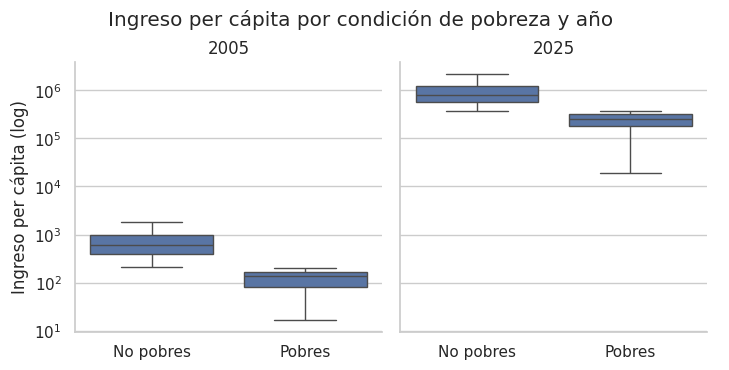

In [ ]:
# quedate solo con filas válidas
d = df[df["IPCF"].notna() & df["pobre"].notna()].copy()

# winsoriza suavemente para mejor lectura opcional (no afecta análisis)
q99 = d["IPCF"].quantile(0.99)
d["IPCF_plot"] = d["IPCF"].clip(upper=q99)

sns.set_theme(context="notebook", style="whitegrid")

g = sns.catplot(
    data=d, x="pobre", y="IPCF_plot",
    kind="box", col="ANIO",
    showfliers=False, height=4.0, aspect=0.9
)
g.set(yscale="log")
g.set_xticklabels(["No pobres","Pobres"])
g.set_axis_labels("", "Ingreso per cápita (log)")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Ingreso per cápita por condición de pobreza y año")



# Cambiar etiquetas de las columnas
new_titles = ["2005", "2025"]
for ax, title in zip(g.axes.flat, new_titles):
    ax.set_title(title)


plt.show()
